In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import simpson

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

# **Flujos**

In [31]:
df_pb = pd.read_csv('Flujo_PB.csv',sep = ';')
df_md = pd.read_csv('Flujo_MD_tot.csv',sep = ';')

In [32]:
# Datos del paper de LX-ZEP
masa_PB = df_pb[df_pb.columns[0]] # Mev/c²
flujo_PB = df_pb[df_pb.columns[1]] # 1/(cm sr s)
masa_MD = df_md[df_md.columns[0]] # Mev/c²
flujo_MD = df_md[df_md.columns[1]] # 1/(cm sr s)



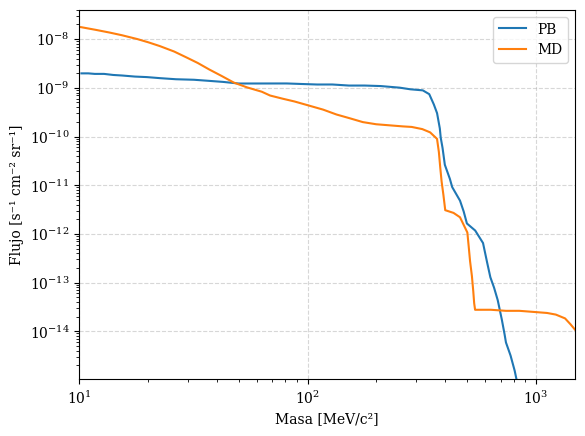

In [33]:
plt.plot(masa_PB, flujo_PB, '-', label='PB')
plt.plot(masa_MD, flujo_MD, '-', label='MD')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1,np.max(masa_MD))
plt.ylim(np.min(flujo_PB),4e-8)
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻² sr⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [34]:
# Interpolación de los datos y cambio de unidades
masa_pb_ = df_pb[df_pb.columns[0]] # Mev/c²
flujo_pb_ =2*np.pi*df_pb[df_pb.columns[1]] # 1/(cm sr s) -> 1/(cm s)
masa_md_ = df_md[df_md.columns[0]] # Mev/c²
flujo_md_ =2*np.pi*df_md[df_md.columns[1]] # 1/(cm sr s) -> 1/(cm s)
orden = np.argsort(masa_pb_)
orden_md = np.argsort(masa_md_)
masa_pb_ = masa_pb_[orden]
flujo_pb_ = flujo_pb_[orden]
masa_md_ = masa_md_[orden_md]
flujo_md_ = flujo_md_[orden_md] 
# Intemasa_md = np.logspace(np.log10(np.min(masa_md)),np.log10(np.max(masa_md)),100)

masa_pb = np.logspace(np.log10(np.min(masa_pb_)),np.log10(np.max(masa_pb_)),100) # Mev/c²
masa_md = np.logspace(np.log10(np.min(masa_md_)),np.log10(np.max(masa_md_)),100) # Mev/c²
flujo_pb_interpolado = interp1d(masa_pb_, flujo_pb_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_md_interpolado = interp1d(masa_md_, flujo_md_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_pb = flujo_pb_interpolado(masa_pb) # 1/(cm s)
flujo_md = flujo_md_interpolado(masa_md) # 1/(cm s)

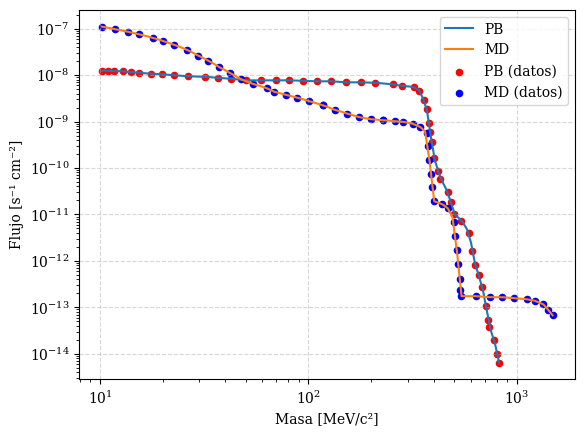

In [35]:
plt.plot(masa_pb, flujo_pb, '-', label='PB')
plt.plot(masa_md, flujo_md, '-', label='MD')
plt.scatter(masa_pb_, flujo_pb_, color='red', label='PB (datos)', s=20)
plt.scatter(masa_md_, flujo_md_, color='blue', label='MD (datos)', s=20)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻²]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [36]:
# Guardo el flujo interpolado
flujo_pb_df = pd.DataFrame({
    'Masa[MeV/c2]': masa_pb,
    'Flujo[s-1cm-2]': flujo_pb
}
)
flujo_md_df = pd.DataFrame({
    'Masa[MeV/c2]': masa_md,
    'Flujo[s-1cm-2]': flujo_md
}
)
flujo_pb_df.to_csv('Flujo_PB_interpolado.csv', index=False)
flujo_md_df.to_csv('Flujo_MD_interpolado.csv', index=False)

# **Sección eficaz**

In [37]:
df_se = pd.read_csv('Seccion_eficaz_DEr_mCP.csv',sep = ';')

In [38]:
Er = np.array(df_se[df_se.columns[0]]) # eV
sigma_er_ = np.array(df_se[df_se.columns[1]]) # cm²/eV
orden = np.argsort(Er)
Er = Er[orden]
sigma_er_ = sigma_er_[orden]

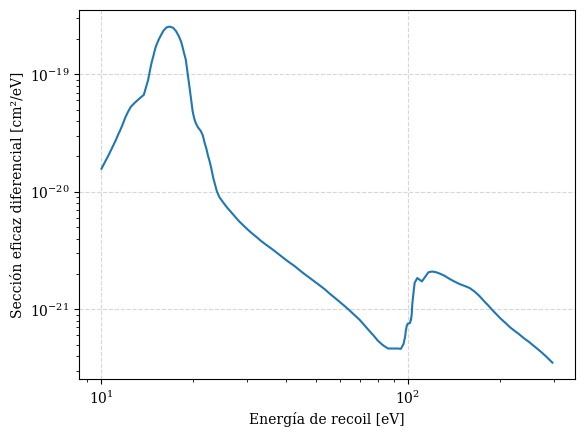

In [39]:
plt.plot(Er, sigma_er_, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)

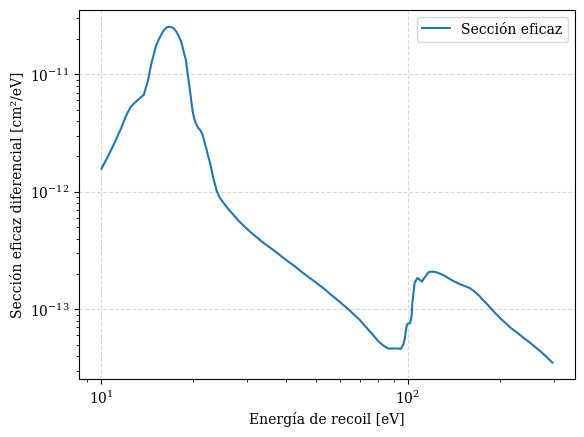

In [40]:
sigma_er = np.array((df_se[df_se.columns[1]]))*(1e-2/1e-6)**2 # eps=1e-6--> 1e-2
plt.plot(Er, sigma_er, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

In [41]:
sec_eficaz_Si_mCP = pd.DataFrame({
    'Er[eV]': Er,
    'Seccion_ef[cm2/eV]': sigma_er
}
)

sec_eficaz_Si_mCP.to_csv('Seccion_eficaz_Si_mCP.csv', index=False)

# **Espectros**

In [42]:
sec_eficaz = pd.read_csv('Seccion_eficaz_Si_mCP.csv')

flujo_pb_df = pd.read_csv('Flujo_PB_interpolado.csv')

flujo_md_df = pd.read_csv('Flujo_MD_interpolado.csv')

In [43]:
# Energía de recoil y sección eficaz diferencial
Er = sec_eficaz[sec_eficaz.columns[0]] # eV
sigma_er = sec_eficaz[sec_eficaz.columns[1]] # cm²/eV

In [44]:
# Masas y flujos de mcp para PB y MD
masa_pb = np.array(flujo_pb_df[flujo_pb_df.columns[0]]) # MeV/c²
flujo_pb = np.array(flujo_pb_df[flujo_pb_df.columns[1]]) # 1/(cm² s)
masa_md = np.array(flujo_md_df[flujo_md_df.columns[0]]) # MeV/c²
flujo_md = np.array(flujo_md_df[flujo_md_df.columns[1]]) # 1/(cm² s)

In [45]:
# Cálculo de los espectros diferenciales de eventos para PB y MD
espectros_pb = np.zeros((len(masa_pb),len(Er))) # 1/(eV s)
espectros_md = np.zeros((len(masa_md),len(Er))) # 1/(eV s)
for i in range(len(masa_pb)):
    espectros_pb[i,:] = flujo_pb[i]*sigma_er

for i in range(len(masa_md)):
    espectros_md[i,:] = flujo_md[i]*sigma_er

In [46]:
# Multiplico por la densidad de átomos por unidad de masa del Silicio
Na = 6.022e23 # átomos/mol
A_Si = 28.0855 * 1e-3 # kg/mol
n_Si_ = Na / A_Si # átomos/g
n_Si = n_Si_  # átomos/kg
espectros_pb = espectros_pb * n_Si # 1/(eV s kg)
espectros_md = espectros_md * n_Si # 1/(eV s kg)


In [47]:
# Paso de 1/s a 1/d
espectros_pb = espectros_pb * 86400 # 1/(eV day kg)
espectros_md = espectros_md * 86400 # 1/(eV day kg)

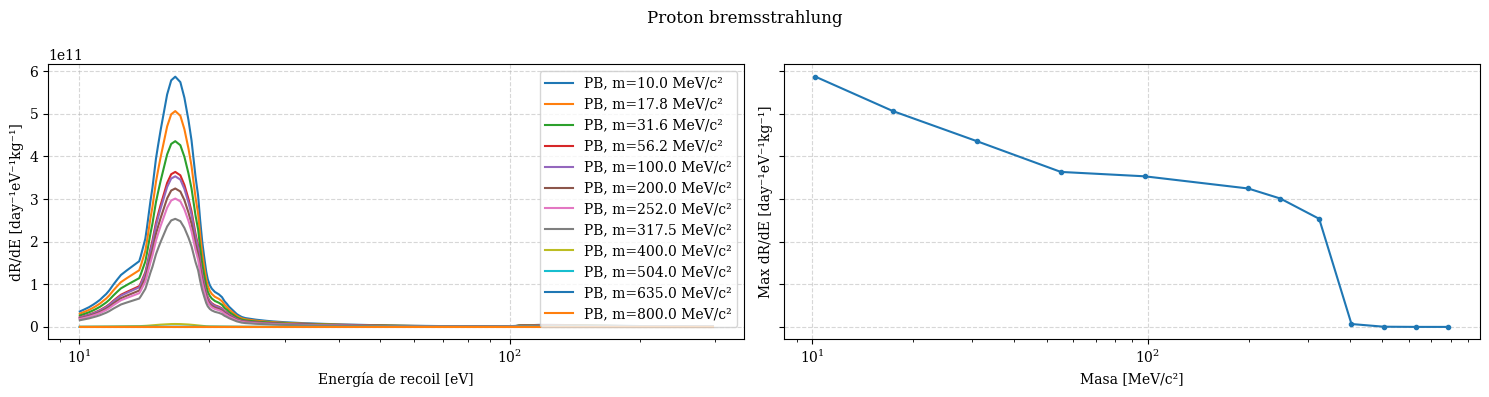

In [48]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(15,4), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),7)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(espectros_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('dR/dE [day⁻¹eV⁻¹kg⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max dR/dE [day⁻¹eV⁻¹kg⁻¹]')
fig.suptitle('Proton bremsstrahlung')
plt.tight_layout()

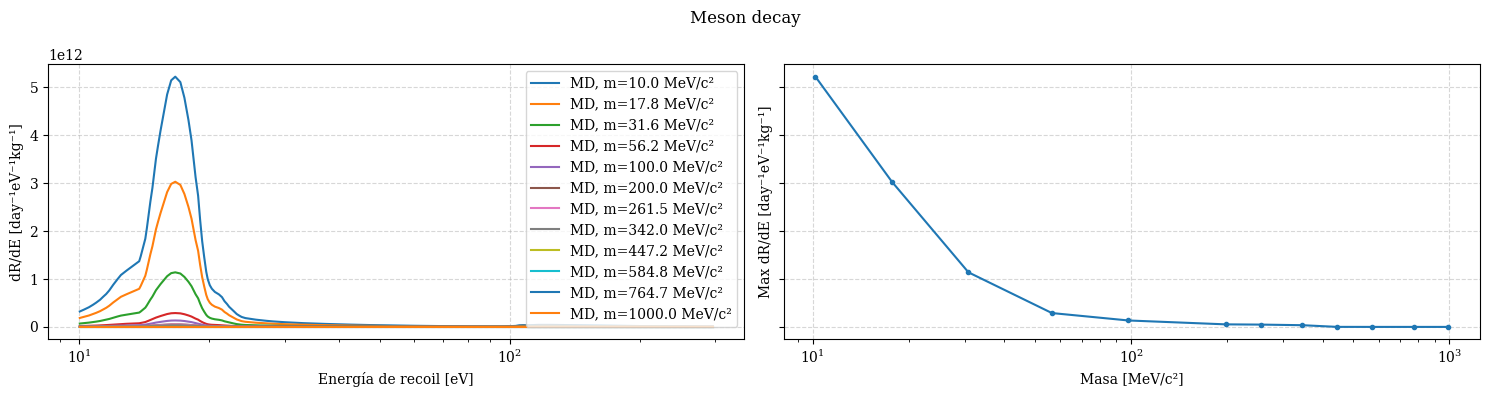

In [49]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(15,4), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),7)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(espectros_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('dR/dE [day⁻¹eV⁻¹kg⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max dR/dE [day⁻¹eV⁻¹kg⁻¹]')
fig.suptitle('Meson decay')
plt.tight_layout()

In [50]:
df_espectros_pb = pd.DataFrame(espectros_pb, columns=Er)
df_espectros_pb.insert(0, 'Masa_mcp[MeV/c²]\Er[eV]', masa_pb)
df_espectros_pb.to_csv('Espectros_PB.csv', index=False)

<>:2: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:2: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
/tmp/ipykernel_20787/2939262709.py:2: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
  df_espectros_pb.insert(0, 'Masa_mcp[MeV/c²]\Er[eV]', masa_pb)


# Calculo de integral sobre energía:

In [51]:
# Importamos los rates diferenciales 
rate_dif_pb = np.copy(espectros_pb) # 1/(eV day kg)
rate_dif_md = np.copy(espectros_md) # 1/(eV day kg)

In [52]:
# Importamos las probabilidades de generar un par electrón hueco

path = '/home/lurishi/Escritorio/Doctorado/Data_Er_a_e'
df_PC_1 = pd.read_csv(path+'/1e-.csv',sep = ';')
df_PC_2 = pd.read_csv(path+'/2e-.csv',sep = ';')
df_PC_3 = pd.read_csv(path+'/3e-.csv',sep = ';')
df_PC_4 = pd.read_csv(path+'/4e-.csv',sep = ';')
df_PC_5 = pd.read_csv(path+'/5e-.csv',sep = ';')
df_PC_6 = pd.read_csv(path+'/6e-.csv',sep = ';')
df_PC_7 = pd.read_csv(path+'/7e-.csv',sep = ';')

Er_pc1, Er_pc2, Er_pc3, Er_pc4, Er_pc5, Er_pc6, Er_pc7 = df_PC_1[df_PC_1.columns[0]], df_PC_2[df_PC_2.columns[0]], df_PC_3[df_PC_3.columns[0]], df_PC_4[df_PC_4.columns[0]], df_PC_5[df_PC_5.columns[0]], df_PC_6[df_PC_6.columns[0]], df_PC_7[df_PC_7.columns[0]]
P_PC_1,P_PC_2, P_PC_3, P_PC_4, P_PC_5, P_PC_6, P_PC_7 = df_PC_1[df_PC_1.columns[1]], df_PC_2[df_PC_2.columns[1]], df_PC_3[df_PC_3.columns[1]], df_PC_4[df_PC_4.columns[1]], df_PC_5[df_PC_5.columns[1]], df_PC_6[df_PC_6.columns[1]], df_PC_7[df_PC_7.columns[1]]

Er_lista = [Er_pc1, Er_pc2, Er_pc3, Er_pc4, Er_pc5, Er_pc6, Er_pc7]
P_PC_lista = [P_PC_1, P_PC_2, P_PC_3, P_PC_4, P_PC_5, P_PC_6, P_PC_7]

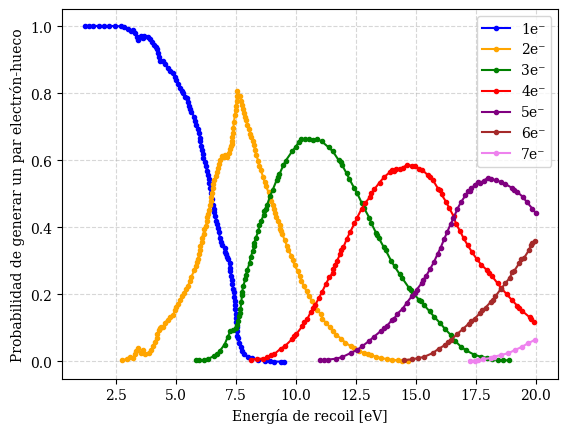

In [53]:
plt.plot(Er_pc1, P_PC_1, '.-',label = '1e⁻',color = 'blue')
plt.plot(Er_pc2, P_PC_2, '.-',label = '2e⁻',color = 'orange')
plt.plot(Er_pc3, P_PC_3, '.-',label = '3e⁻',color = 'green')
plt.plot(Er_pc4, P_PC_4, '.-',label = '4e⁻',color = 'red')
plt.plot(Er_pc5, P_PC_5, '.-',label = '5e⁻',color = 'purple')
plt.plot(Er_pc6, P_PC_6, '.-',label = '6e⁻',color = 'brown')
plt.plot(Er_pc7, P_PC_7, '.-',label = '7e⁻',color = 'violet')
plt.grid(linestyle='--', alpha=0.5)
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Probabilidad de generar un par electrón-hueco')
plt.legend()

In [54]:
Er_pb_md = Er
rate_integrado_pb = pd.DataFrame(columns = ['masa[MeV/c2]\Rate[day⁻¹kg⁻¹]', '1e','2e','3e','4e','5e','6e','7e'])
rate_integrado_md = pd.DataFrame(columns = ['masa[MeV/c2]\Rate[day⁻¹kg⁻¹]', '1e','2e','3e','4e','5e','6e','7e'])
for i in range(len(masa_pb)):

    rate_pb = np.asarray(rate_dif_pb[i, :], dtype=float)
    rate_md = np.asarray(rate_dif_md[i, :], dtype=float)
    
    fila_pb = []
    fila_md = []
    for j in range(len(Er_lista)):
        Er_pc = Er_lista[j]
        P_PC = P_PC_lista[j]
        Er_pb_md = np.asarray(Er, dtype=float)   # keV
        Er_pc = np.asarray(Er_pc, dtype=float)
        E_min = max(Er_pb_md.min(), Er_pc.min())
        E_max = min(Er_pb_md.max(), Er_pc.max())
        print(f'E_min: {E_min}, E_max: {E_max}')
        if E_min >= E_max:
            integral_pb = 0.0
            integral_md = 0.0
            fila_pb.append(integral_pb)
            fila_md.append(integral_md)
            
        else:
            E_common = np.linspace(E_min, E_max, 1000)
            f_prob_pc = interp1d(Er_pc, P_PC, kind='linear', bounds_error=False, fill_value=np.nan)
            f_rate_pb = interp1d(Er_pb_md, rate_pb, kind='linear', bounds_error=False, fill_value=np.nan)
            f_rate_md = interp1d(Er_pb_md, rate_md, kind='linear', bounds_error=False, fill_value=np.nan)
            
            integrand_pb = f_prob_pc(E_common) * f_rate_pb(E_common)
            integrand_md = f_prob_pc(E_common) * f_rate_md(E_common)
            
            integral_pb = simpson(integrand_pb, E_common)
            integral_md = simpson(integrand_md, E_common)
            
            fila_pb.append(integral_pb)
            fila_md.append(integral_md)
    rate_integrado_pb.loc[len(rate_integrado_pb)] = [masa_pb[i]] + fila_pb
    rate_integrado_md.loc[len(rate_integrado_md)] = [masa_md[i]] + fila_md


<>:2: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:3: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:2: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:3: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
/tmp/ipykernel_20787/76107979.py:2: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  rate_integrado_pb = pd.DataFrame(columns = ['masa[MeV/c2]\Rate[day⁻¹kg⁻¹]', '1e','2e','3e','4e','5e','6e','7e'])
/tmp/ipykernel_20787/76107979.py:3: SyntaxWarning: "\R" is an invalid escape sequence. Suc

E_min: 10.027190024098449, E_max: 9.52229
E_min: 10.027190024098449, E_max: 14.6797
E_min: 10.027190024098449, E_max: 18.8753
E_min: 10.027190024098449, E_max: 19.9214
E_min: 11.0114, E_max: 19.9952
E_min: 14.5065, E_max: 19.9645
E_min: 17.2755, E_max: 19.9829
E_min: 10.027190024098449, E_max: 9.52229
E_min: 10.027190024098449, E_max: 14.6797
E_min: 10.027190024098449, E_max: 18.8753
E_min: 10.027190024098449, E_max: 19.9214
E_min: 11.0114, E_max: 19.9952
E_min: 14.5065, E_max: 19.9645
E_min: 17.2755, E_max: 19.9829
E_min: 10.027190024098449, E_max: 9.52229
E_min: 10.027190024098449, E_max: 14.6797
E_min: 10.027190024098449, E_max: 18.8753
E_min: 10.027190024098449, E_max: 19.9214
E_min: 11.0114, E_max: 19.9952
E_min: 14.5065, E_max: 19.9645
E_min: 17.2755, E_max: 19.9829
E_min: 10.027190024098449, E_max: 9.52229
E_min: 10.027190024098449, E_max: 14.6797
E_min: 10.027190024098449, E_max: 18.8753
E_min: 10.027190024098449, E_max: 19.9214
E_min: 11.0114, E_max: 19.9952
E_min: 14.5065, E_

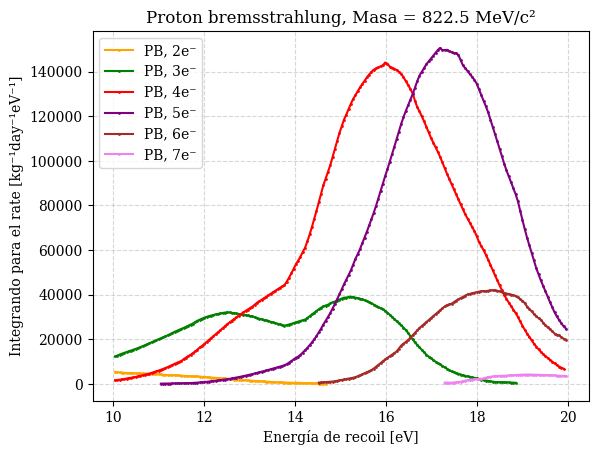

In [55]:
E_min = 10
E_max = 20
E_common = np.linspace(E_min, E_max, 200)
f_prob_pc_2 = interp1d(Er_pc2, P_PC_2, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_3 = interp1d(Er_pc3, P_PC_3, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_4 = interp1d(Er_pc4, P_PC_4, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_5 = interp1d(Er_pc5, P_PC_5, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_6 = interp1d(Er_pc6, P_PC_6, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_7 = interp1d(Er_pc7, P_PC_7, kind='linear', bounds_error=False, fill_value=np.nan)
f_rate_pb = interp1d(Er_pb_md, rate_pb, kind='linear', bounds_error=False, fill_value=np.nan)
f_rate_md = interp1d(Er_pb_md, rate_md, kind='linear', bounds_error=False, fill_value=np.nan)

integrand_pb_2 = f_prob_pc_2(E_common) * f_rate_pb(E_common)
integrand_md_2 = f_prob_pc_2(E_common) * f_rate_md(E_common)
integrand_pb_3 = f_prob_pc_3(E_common) * f_rate_pb(E_common)
integrand_md_3 = f_prob_pc_3(E_common) * f_rate_md(E_common)
integrand_pb_4 = f_prob_pc_4(E_common) * f_rate_pb(E_common)
integrand_md_4 = f_prob_pc_4(E_common) * f_rate_md(E_common)
integrand_pb_5 = f_prob_pc_5(E_common) * f_rate_pb(E_common)
integrand_md_5 = f_prob_pc_5(E_common) * f_rate_md(E_common)
integrand_pb_6 = f_prob_pc_6(E_common) * f_rate_pb(E_common)
integrand_md_6 = f_prob_pc_6(E_common) * f_rate_md(E_common)
integrand_pb_7 = f_prob_pc_7(E_common) * f_rate_pb(E_common)
integrand_md_7 = f_prob_pc_7(E_common) * f_rate_md(E_common)

plt.plot(E_common, integrand_pb_2,'-', marker='.',markersize=2, label='PB, 2e⁻',color = 'orange')
plt.plot(E_common, integrand_pb_3, '-', marker='.', markersize=2, label='PB, 3e⁻',color = 'green')
plt.plot(E_common, integrand_pb_4, '-', marker='.', markersize=2, label='PB, 4e⁻',color = 'red')
plt.plot(E_common, integrand_pb_5, '-', marker='.', markersize=2, label='PB, 5e⁻',color = 'purple')
plt.plot(E_common, integrand_pb_6, '-', marker='.', markersize=2, label='PB, 6e⁻',color = 'brown')
plt.plot(E_common, integrand_pb_7, '-', marker='.', markersize=2, label='PB, 7e⁻',color = 'violet')
plt.grid(linestyle='--', alpha=0.5)
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Integrando para el rate [kg⁻¹day⁻¹eV⁻¹]')
plt.title(f'Proton bremsstrahlung, Masa = {masa_pb[-1]:.1f} MeV/c²')
plt.legend()

In [56]:
eff2 = 0.51*0.96*0.94
eff3 = 0.64*0.96*0.93
eff4 = 0.71*0.96*0.92
eff5 = 0.75*0.95*0.91
eff6 = 0.78*0.95*0.90
eff7 = 0.80*0.95*0.89
rates_pb_final = rate_integrado_pb.copy()
rates_md_final = rate_integrado_md.copy()
rates_pb_final[rates_pb_final.columns[2]] = rate_integrado_pb[rates_pb_final.columns[2]]*eff2
rates_pb_final[rates_pb_final.columns[3]] = rate_integrado_pb[rates_pb_final.columns[3]]*eff3
rates_pb_final[rates_pb_final.columns[4]] = rate_integrado_pb[rates_pb_final.columns[4]]*eff4
rates_pb_final[rates_pb_final.columns[5]] = rate_integrado_pb[rates_pb_final.columns[5]]*eff5
rates_pb_final[rates_pb_final.columns[6]] = rate_integrado_pb[rates_pb_final.columns[6]]*eff6
rates_pb_final[rates_pb_final.columns[7]] = rate_integrado_pb[rates_pb_final.columns[7]]*eff7
rates_md_final[rates_md_final.columns[2]] = rate_integrado_md[rates_md_final.columns[2]]*eff2
rates_md_final[rates_md_final.columns[3]] = rate_integrado_md[rates_md_final.columns[3]]*eff3
rates_md_final[rates_md_final.columns[4]] = rate_integrado_md[rates_md_final.columns[4]]*eff4
rates_md_final[rates_md_final.columns[5]] = rate_integrado_md[rates_md_final.columns[5]]*eff5
rates_md_final[rates_md_final.columns[6]] = rate_integrado_md[rates_md_final.columns[6]]*eff6
rates_md_final[rates_md_final.columns[7]] = rate_integrado_md[rates_md_final.columns[7]]*eff7

In [57]:
rates_pb_final.to_csv('Rates_PB_eps_1e-2_m10-800.csv', index=False)
rates_md_final.to_csv('Rates_MD_eps_1e-2_m10-800.csv', index=False)

In [58]:
rates_md_final.head()

,masa[MeV/c2]\Rate[day⁻¹kg⁻¹],1e,2e,3e,4e,5e,6e,7e
0,10.189400,0.0,9.237051e+10,1.941606e+12,6.156740e+12,5.756543e+12,1.483721e+12,9.394367e+10
1,10.715336,0.0,8.880301e+10,1.866618e+12,5.918956e+12,5.534216e+12,1.426418e+12,9.031541e+10
2,11.268419,0.0,8.505137e+10,1.787759e+12,5.668900e+12,5.300413e+12,1.366156e+12,8.649988e+10
3,11.850050,0.0,8.113862e+10,1.705514e+12,5.408105e+12,5.056570e+12,1.303307e+12,8.252049e+10
4,12.461703,0.0,7.776554e+10,1.634613e+12,5.183280e+12,4.846359e+12,1.249126e+12,7.908997e+10
